In [31]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import copy

import numpy as np 

from astropy.io import fits
from astropy.table import Table, Column
from astropy.cosmology import FlatLambdaCDM

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

In [48]:
def v_to_gaia_g(v_mag, color, color_type='V-R', return_sig=False):
    """Convert Johnson V-band magnitude to Gaia G magnitude"""
    if color_type == 'V-R':
        G_mag = v_mag - 0.02269 + 0.01784 * color - 1.016 * (color ** 2) + 0.2225 * (color ** 3)
        G_sigma = 0.04895
    elif color_type == 'V-I':
        G_mag = v_mag - 0.01746 + 0.00809 * color - 0.281 * (color ** 2) + 0.0366 * (color ** 3)
        G_sigma = 0.04670
    elif color_type == 'B-V':
        G_mag = v_mag - 0.02907 - 0.02385 * color - 0.230 * (color ** 2) - 0.0018 * (color ** 3)
        G_sigma = 0.04895
    else:
        raise ValueError("Wrong color type!")
        
    if return_sig: 
        return G_mag, G_sigma
    return G_mag

- About the resolution of Gaia.
    - The instantaneous spatial resolution, in the scanning direction, is comparable to that of the Hubble Space Telescope and Gaia is surveying the whole sky. (from [the Gaia mission paper](https://ui.adsabs.harvard.edu/abs/2016A%26A...595A...1G/abstract))
    - Based on the [Gaia DR2 paper](https://www.aanda.org/articles/aa/pdf/2018/08/aa33051-18.pdf): "For Gaia DR2 (upper, red curve) source pairs below 0.4–0.5 arcsec are rarely resolved, but the resolution improves rapidly and above 2.2 arcsec practically all pairs are resolved."
    - Based on the [Gaia DR2 website](https://www.cosmos.esa.int/web/gaia/dr2): The effective angular resolution of the survey has improved with respect to DR1 and is about 0.4 arcsec.
    - Gaia will provide a homogeneous, magnitude-limited sample of unresolved galaxies. For resolved galaxies, the sampling function is complicated as **the onboard detection depends on the contrast between any point-like, central element (bulge) and any extended structure, convolved with the scanning direction.**

- Gaia's photometry comprises:
    1. broad-band white-light G-band fluxes obtained in the astrometric instrument, and
    2. low-resolution spectro-photometry obtained in the Blue and Red Photometers (BP and RP).
    - The wavelength coverage of the astrometric instrument, defining the white-light G band, is **~330-1050 nm**.

- About the systematics in Gaia DR2 photometry
    - [Expected photometric performance can be found here](https://www.cosmos.esa.int/web/gaia/science-performance)
    - The Gaia Data Release 2 photometry is affected by some systematic errors, as already mentioned by Evans et al. (2018) and Arenou et al. (2018). These effects include complex features for faint sources (G greater than about 17), likely caused by problems in the background calibration and contamination from nearby sources. For bright sources (G less than about 6), saturation causes systematic dependencies for which Evans et al. (2018) provide an empirical correction.
    - A systematic trend with magnitude has been detected in the G band at magnitudes brighter than about 16.5 by comparing Gaia DR2 data with synthetic photometry of CALSPEC sources (Casagrande & VandenBerg 2018, Weiler 2018). This trend is approximately linear.
    - For more systematics, check out the [known issues in DR2](https://www.cosmos.esa.int/web/gaia/dr2-known-issues)
    - The photometric standard errors of the integrated G-band, BP-band, and RP-band are calculated following the recipe outlined in [GAIA-JDB-022](http://www.rssd.esa.int/doc_fetch.php?id=448635). The standard-error calculation includes all known instrumental effects, including straylight as measured in flight.
    
- Photometric reduction
    - [Gaia Data Release 2. Processing of the photometric data](https://ui.adsabs.harvard.edu/abs/2018A%26A...616A...3R/abstract)
    
- About the photometry of unresolved galaxies:
    - Unresolved, early-type elliptical galaxies and galaxy bulges will be mostly detected by Gaia, even with effective radii of several arcseconds, while late-type spiral galaxies, even those with weak bulges, will mostly remain undetected (de Bruijne et al. 2015). (from [the Gaia mission paper](https://ui.adsabs.harvard.edu/abs/2016A%26A...595A...1G/abstract))
    - "In essence, the detection algorithm finds peaks in flat-fielded, local background-subtracted sky-mapper sample data and then accepts these as detections if their shape is consistent with that of a point source and their flux exceeds a certain, user-configurable threshold"
    - [de Bruijne et al. 2015: Detecting stars, galaxies, and asteroids with Gaia](https://ui.adsabs.harvard.edu/abs/2015A%26A...576A..74D/abstract) 
        - Section 3.5 is about the detection of unresolved galaxies.
        - "We find that, whereas the optimised rejection parameters have no significant impact on the detectability of pure de Vaucouleurs profiles, they do significantly improve the detection of pure exponential-disk profiles, and hence also the detection of unresolved external galaxies with intermediate profiles."
        - "As Gaia is primarily a Galactic astrometry mission, we do not take galaxies into account for the optimisation of the rejection parameter"..."We do not consider the detection performance of external galaxies and/or asteroids in the merit function since these objects are not a core science product: Gaia is a Galactic astrometry mission and the on-board detection should be optimised for stars."
        - The impact of rejection algorithm is examed by simulation using GIBIS: radii between 0.2 to 2.0 arcsec; magnitude V=14-20 mag.
        - Fig. 12: single-star detection probability.
        - Fig. 22-23: detection probability for galaxies with different properties.
        - Small-scale (noise) variations are due to the position of the galaxies in the focal plane and their posi- tion in the sky: since there are gaps between the CCD rows, and since some profiles may even fall outside the focal plane in some transits, the simulated profiles are a priori not expected to be observed in all transits and some random variation is expected.
    - [Detection of galaxies with Gaia](https://ui.adsabs.harvard.edu/abs/2014A%26A...568A.124D/abstract)
        - "A heterogeneous population of elliptical galaxies and bulges will be observable by Gaia. This nearby Universe sample of galaxies should constitute a very rich and interesting sample for studying their structural properties and their distribution."
        

In [49]:
v_to_gaia_g(-12.3, 0.7, color_type='V-R')

-12.731724500000002

In [26]:
# Redshift array
z_arr = np.logspace(-5, np.log10(2e-2), 1000)

# Luminosity distance
d_mpc = cosmo.luminosity_distance(z_arr).value

# Physical scale
arcsec_per_kpc = cosmo.arcsec_per_kpc_proper(z_arr).value

# Distance modulu
dist_mod = cosmo.distmod(z_arr).value

Text(0.5, 0, '$\\rm Redshift$')

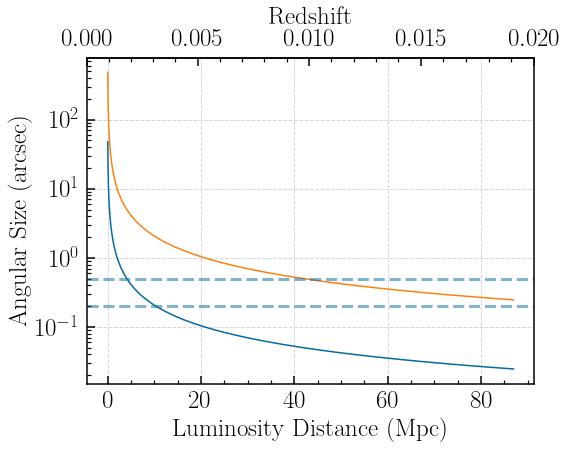

In [46]:
fig = plt.figure(figsize=(8, 6))
plt.subplots_adjust(wspace=0, hspace=0)

ax = plt.subplot(111)
ax.set_yscale('log')

ax.plot(d_mpc, cosmo.arcsec_per_kpc_proper(z_arr) * 0.01)
ax.plot(d_mpc, cosmo.arcsec_per_kpc_proper(z_arr) * 0.1)

ax.set_xlabel(r'$\rm Luminosity\ Distance\ (Mpc)$', fontsize=25)
ax.set_ylabel(r'$\rm Angular\ Size\ (arcsec)$', fontsize=25)

# 0.4-0.5 arcsec
ax.axhline(0.2, linestyle='--', linewidth=3.0, alpha=0.5)
ax.axhline(0.5, linestyle='--', linewidth=3.0, alpha=0.5)

def forward(x):
    return np.interp(x, z_arr, d_mpc)

def inverse(x):
    return np.interp(x, d_mpc, z_arr)

secax = ax.secondary_xaxis('top', functions=(inverse, forward))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel(r'$\rm Redshift$', fontsize=25)

Text(0.5, 0, '$\\rm Redshift$')

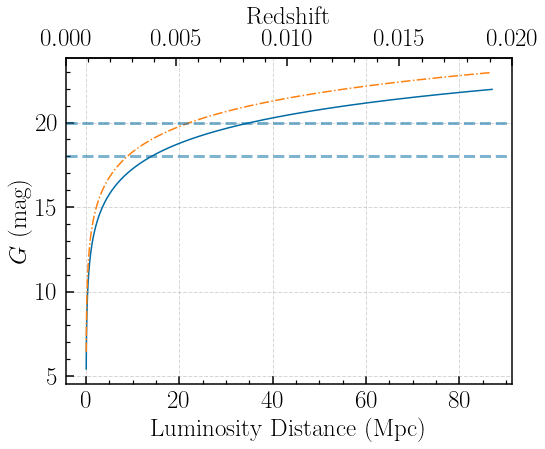

In [51]:
fig = plt.figure(figsize=(8, 6))
plt.subplots_adjust(wspace=0, hspace=0)

ax = plt.subplot(111)

ax.plot(d_mpc, v_to_gaia_g(-12.3, 0.7, color_type='V-R') + dist_mod)
ax.plot(d_mpc, v_to_gaia_g(-12.3, 0.7, color_type='V-R') + dist_mod + 1.0, linestyle='-.')

ax.set_xlabel(r'$\rm Luminosity\ Distance\ (Mpc)$', fontsize=25)
ax.set_ylabel(r'$G\ (\rm mag)$', fontsize=25)

# 0.4-0.5 arcsec
ax.axhline(18.0, linestyle='--', linewidth=3.0, alpha=0.5)
ax.axhline(20.0, linestyle='--', linewidth=3.0, alpha=0.5)

def forward(x):
    return np.interp(x, z_arr, d_mpc)

def inverse(x):
    return np.interp(x, d_mpc, z_arr)

secax = ax.secondary_xaxis('top', functions=(inverse, forward))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel(r'$\rm Redshift$', fontsize=25)